# 01 - Data Exploration

This notebook explores the raw DDXPlus training split stored under `app/data/raw/ddxplus` and shows the structure of the input evidence tokens and disease labels that will be used for the ML workflow.

In [12]:
from pathlib import Path
import ast
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# Use the known project root so the notebook is stable regardless of kernel cwd.
repo_root = Path(r"c:\healix-ai-medical-assistant")
raw_path = repo_root / "app" / "data" / "raw" / "ddxplus" / "train.csv"

if not raw_path.exists():
    raise FileNotFoundError(f"Raw dataset not found: {raw_path}")

df = pd.read_csv(raw_path)
print("Dataset loaded from:", raw_path)
print("Shape:", df.shape)
print("Columns:", list(df.columns))

Dataset loaded from: c:\healix-ai-medical-assistant\app\data\raw\ddxplus\train.csv
Shape: (1025602, 6)
Columns: ['AGE', 'DIFFERENTIAL_DIAGNOSIS', 'SEX', 'PATHOLOGY', 'EVIDENCES', 'INITIAL_EVIDENCE']


In [ ]:
# Basic dataset overview
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
print("Unique diseases:", df["PATHOLOGY"].nunique())
print("\nFirst 5 rows:")
display(df.head())

Rows: 1025602
Columns: 6

First 5 rows:


,AGE,DIFFERENTIAL_DIAGNOSIS,SEX,PATHOLOGY,EVIDENCES,INITIAL_EVIDENCE
0,18,"[['Bronchitis', 0.19171203430383882], ['Pneumo...",M,URTI,"['E_48', 'E_50', 'E_53', 'E_54_@_V_161', 'E_54...",E_91
1,21,"[['HIV (initial infection)', 0.518950056440760...",M,HIV (initial infection),"['E_9', 'E_27', 'E_50', 'E_51', 'E_53', 'E_54_...",E_50
2,19,"[['Bronchitis', 0.11278064619119596], ['Pneumo...",F,Pneumonia,"['E_53', 'E_54_@_V_179', 'E_54_@_V_192', 'E_55...",E_77
3,34,"[['URTI', 0.23859396799565236], ['Cluster head...",F,URTI,"['E_48', 'E_53', 'E_54_@_V_183', 'E_55_@_V_89'...",E_53
4,36,"[['URTI', 0.23677812769175735], ['Influenza', ...",M,URTI,"['E_49', 'E_50', 'E_53', 'E_54_@_V_183', 'E_55...",E_201


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_21304\1660048278.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=disease_counts.values, y=disease_counts.index, orient="h", palette="viridis")


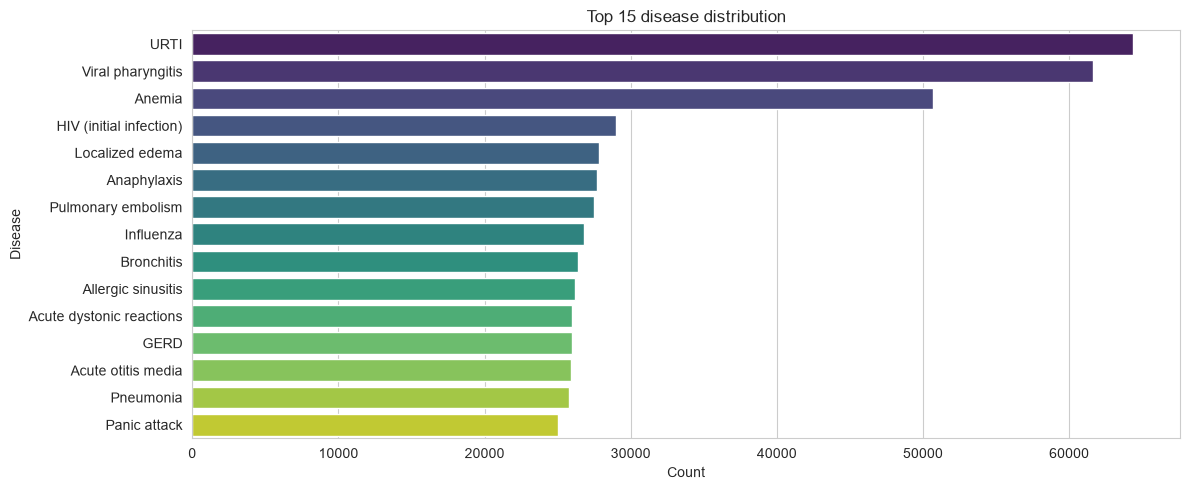

In [8]:
# Disease distribution
plt.figure(figsize=(12, 5))
disease_counts = df["PATHOLOGY"].value_counts().head(15)
sns.barplot(x=disease_counts.values, y=disease_counts.index, orient="h", palette="viridis")
plt.title("Top 15 disease distribution")
plt.xlabel("Count")
plt.ylabel("Disease")
plt.tight_layout()
plt.show()

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_21304\3987170596.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=evidence_counts.values, y=evidence_counts.index, orient="h", palette="magma")


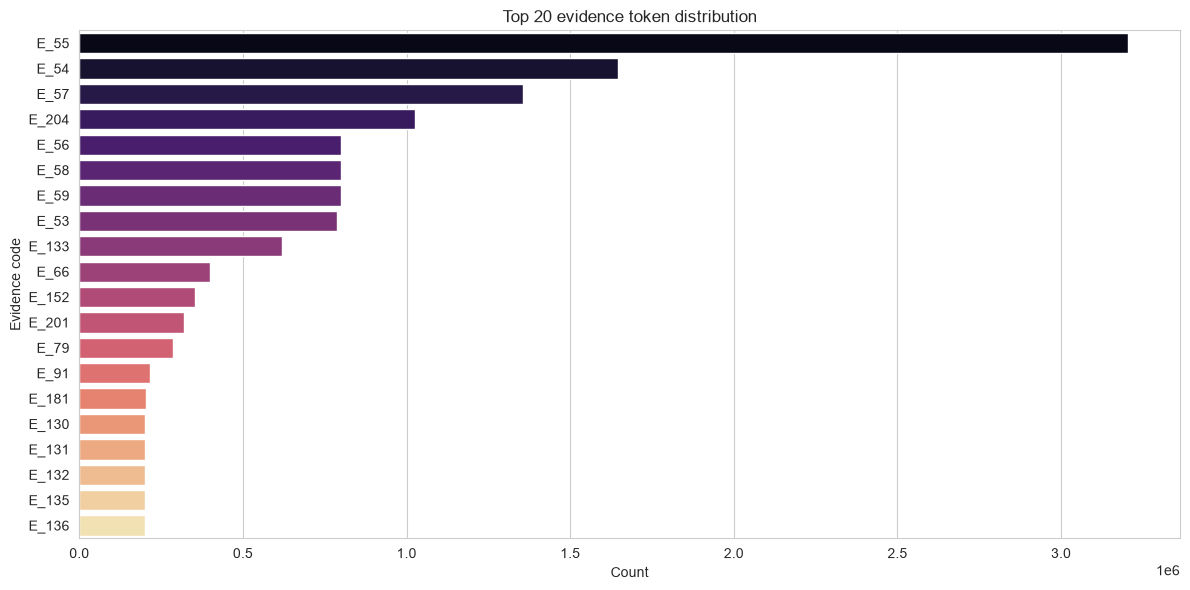

In [9]:
# Evidence distribution

def _base_evidence(token: str) -> str:
    return str(token).split("_@_", 1)[0]

all_evidence_tokens = []
for value in df["EVIDENCES"].fillna("[]"):
    try:
        tokens = ast.literal_eval(value)
    except (ValueError, SyntaxError):
        tokens = []
    all_evidence_tokens.extend([_base_evidence(token) for token in tokens])

evidence_counts = pd.Series(all_evidence_tokens).value_counts().head(20)

plt.figure(figsize=(12, 6))
sns.barplot(x=evidence_counts.values, y=evidence_counts.index, orient="h", palette="magma")
plt.title("Top 20 evidence token distribution")
plt.xlabel("Count")
plt.ylabel("Evidence code")
plt.tight_layout()
plt.show()

In [10]:
# Missing values summary
missing = df.isna().sum()
print(missing[missing > 0].sort_values(ascending=False).head(20))

print("\nMissing rate by key columns:")
for column in ["AGE", "SEX", "PATHOLOGY", "EVIDENCES", "INITIAL_EVIDENCE", "DIFFERENTIAL_DIAGNOSIS"]:
    if column in df.columns:
        rate = df[column].isna().mean()
        print(f"{column}: {rate:.4f}")

Series([], dtype: int64)

Missing rate by key columns:
AGE: 0.0000
SEX: 0.0000
PATHOLOGY: 0.0000
EVIDENCES: 0.0000
INITIAL_EVIDENCE: 0.0000
DIFFERENTIAL_DIAGNOSIS: 0.0000


In [11]:
# Build a compact sample of DDXPlus cases
sample_rows = df.head(3).copy()
for idx, row in sample_rows.iterrows():
    try:
        evidence_tokens = ast.literal_eval(row["EVIDENCES"])
    except (ValueError, SyntaxError):
        evidence_tokens = []

    try:
        differential = ast.literal_eval(row["DIFFERENTIAL_DIAGNOSIS"])
    except (ValueError, SyntaxError):
        differential = []

    print(f"Case {idx}")
    print("Age:", row.get("AGE"))
    print("Sex:", row.get("SEX"))
    print("Pathology:", row.get("PATHOLOGY"))
    print("Initial evidence:", row.get("INITIAL_EVIDENCE"))
    print("Evidence tokens:", evidence_tokens[:10])
    print("Differential diagnosis:", differential[:5])
    print("---")

Case 0
Age: 18
Sex: M
Pathology: URTI
Initial evidence: E_91
Evidence tokens: ['E_48', 'E_50', 'E_53', 'E_54_@_V_161', 'E_54_@_V_183', 'E_55_@_V_89', 'E_55_@_V_108', 'E_55_@_V_167', 'E_56_@_4', 'E_57_@_V_123']
Differential diagnosis: [['Bronchitis', 0.19171203430383882], ['Pneumonia', 0.17579340398940366], ['URTI', 0.1607809719801254], ['Bronchiectasis', 0.12429044460990353], ['Tuberculosis', 0.11367177304035844]]
---
Case 1
Age: 21
Sex: M
Pathology: HIV (initial infection)
Initial evidence: E_50
Evidence tokens: ['E_9', 'E_27', 'E_50', 'E_51', 'E_53', 'E_54_@_V_198', 'E_55_@_V_62', 'E_55_@_V_166', 'E_55_@_V_167', 'E_56_@_7']
Differential diagnosis: [['HIV (initial infection)', 0.5189500564407601], ['Chagas', 0.3217819010436332], ['Scombroid food poisoning', 0.13496758062695968], ['Sarcoidosis', 0.024300461888647054]]
---
Case 2
Age: 19
Sex: F
Pathology: Pneumonia
Initial evidence: E_77
Evidence tokens: ['E_53', 'E_54_@_V_179', 'E_54_@_V_192', 'E_55_@_V_29', 'E_55_@_V_55', 'E_55_@_V_56

## What this notebook shows

- The dataset contains a DDXPlus pathology label and explicit evidence-token annotations.
- The disease distribution is balanced enough to support multi-class classification experiments.
- Evidence is sparse and multi-valued, so preprocessing must carefully parse the token grammar.
- This raw DDXPlus split will be used as the source for the Healix feature-engineering workflow in the rest of the notebooks.